In [1]:
from google.colab import files
uploaded = files.upload()

Saving retail_sales_dataset.csv to retail_sales_dataset.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("retail_sales_dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
total_revenue = df['Total Amount'].sum()

total_orders = df['Transaction ID'].nunique()

average_order_value = total_revenue / total_orders

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Average Order Value:", average_order_value)

Total Revenue: 456000
Total Orders: 1000
Average Order Value: 456.0


In [5]:
top_products = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

print(top_products)

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


In [8]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
monthly_sales = df.groupby('Month')['Total Amount'].sum()

monthly_sales

,Total Amount
Month,
1,36980
2,44060
3,28990
4,33870
5,53150
6,36715
7,35465
8,36960
9,23620


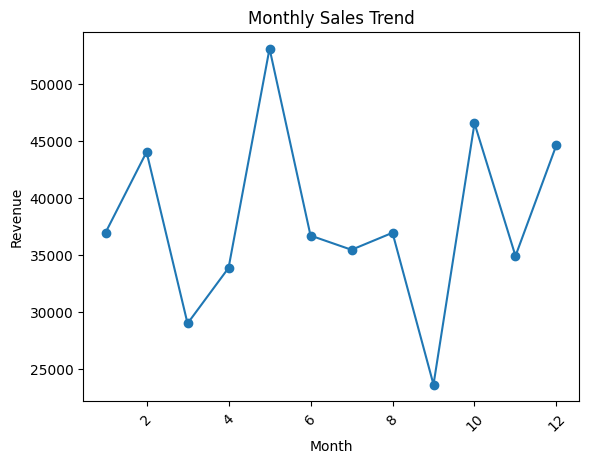

In [9]:
plt.figure()

monthly_sales.plot(kind='line', marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

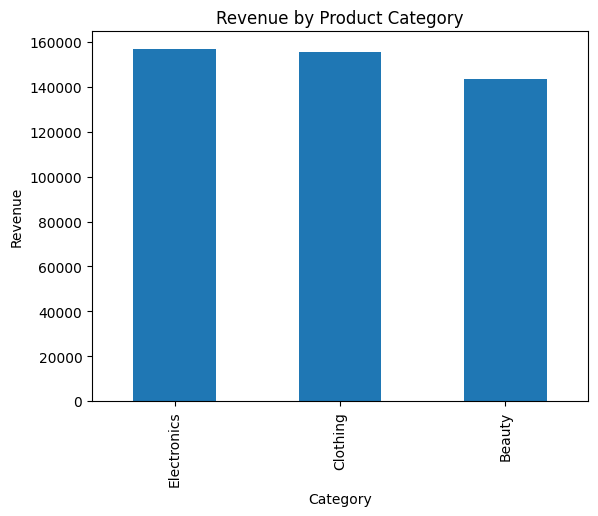

In [10]:
plt.figure()

top_products.plot(kind='bar')

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()

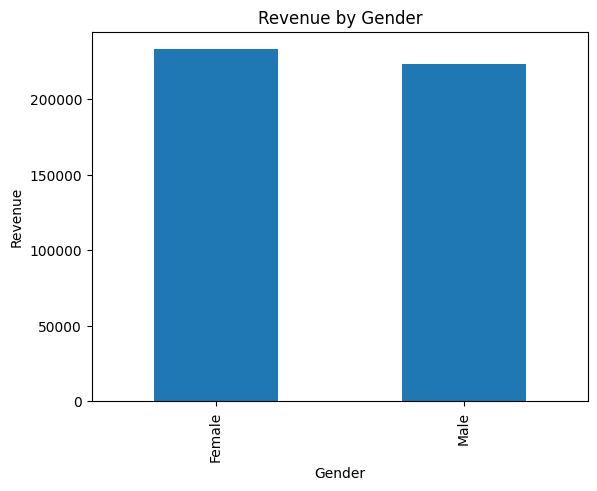

In [11]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()

plt.figure()

gender_sales.plot(kind='bar')

plt.title("Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Revenue")

plt.show()

In [12]:
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 31.0 MB/s eta 0:00:00


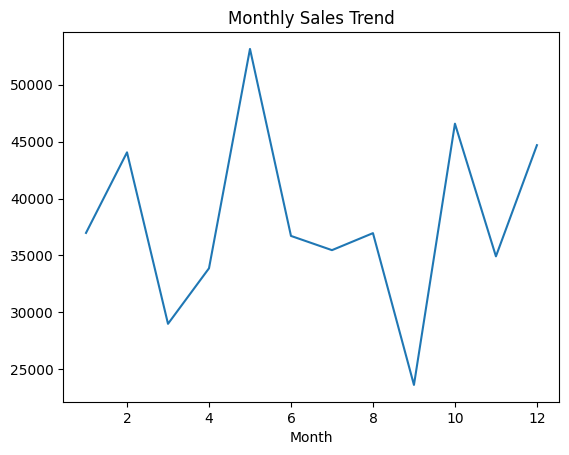

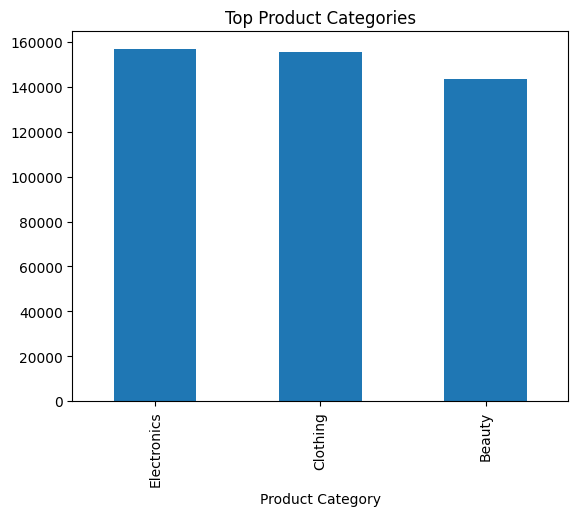

In [13]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table
from reportlab.lib.styles import getSampleStyleSheet

# Save charts
plt.figure()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.savefig("trend.png")

plt.figure()
top_products.plot(kind='bar')
plt.title("Top Product Categories")
plt.savefig("products.png")

# PDF creation
styles = getSampleStyleSheet()

data = [
["KPI", "Value"],
["Total Revenue", total_revenue],
["Total Orders", total_orders],
["Average Order Value", average_order_value]
]

elements = []

elements.append(Paragraph("Retail Sales Business Summary", styles['Title']))
elements.append(Spacer(1,20))
elements.append(Table(data))
elements.append(Spacer(1,20))
elements.append(Image("trend.png", width=400, height=200))
elements.append(Spacer(1,20))
elements.append(Image("products.png", width=400, height=200))

pdf = SimpleDocTemplate("Retail_Summary.pdf")
pdf.build(elements)

In [14]:
files.download("Retail_Summary.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>